### Finke-Watzky 2-Step Model

For the equations:
$$\frac{dA}{dt} = -k_1 A - k_2 A B$$

with initial conditions: $A(0) = A_0$, $B(0) = 0$, and conservation: $A + B = A_0$

Text(0.5, 1.0, 'Finke-Watzky 2-Step Model')

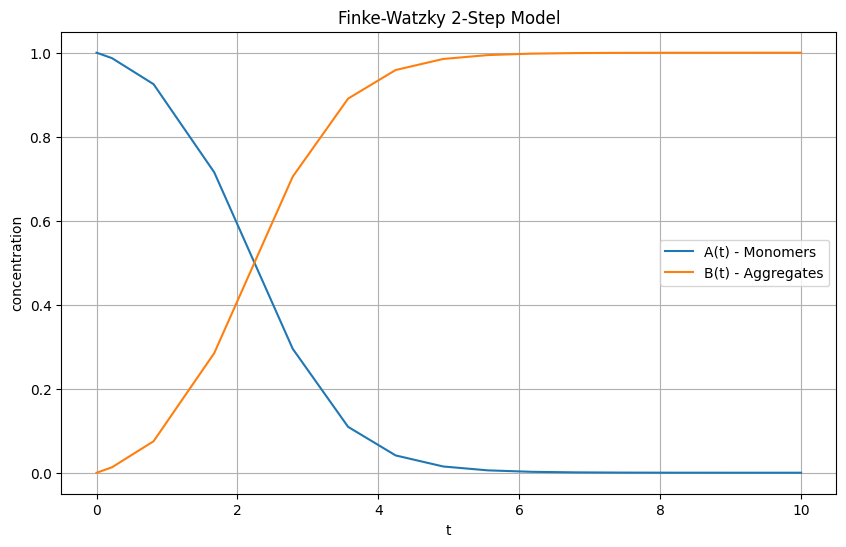

In [30]:
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

# characteristic "2-step" behaviour for small k1 and large k2!
k1, k2, A0 = 0.05, 1.5, 1.0  # nucleation rate, autocatalytic growth rate, initial amount of monomers
ic, t0 = [A0, 0], 0 # initial conditions
tmax = 10

def derivs(t, var):
    dvar = np.zeros(2)
    A, B = var
    dvar[0] = -k1 * A - k2 * A * B  # dA/dt
    dvar[1] = k1 * A + k2 * A * B   # dB/dt (from conservation: A + B = A0)
    return dvar

sol = solve_ivp(derivs, [t0, tmax], ic)

plt.figure(figsize=(10, 6))
plt.plot(sol.t, sol.y[0, :], label='A(t) - Monomers')   # could also just take only A?
plt.plot(sol.t, sol.y[1, :], label='B(t) - Aggregates')
plt.xlabel('t'); plt.ylabel('concentration')
plt.legend(); plt.grid(True); plt.title('Finke-Watzky 2-Step Model')

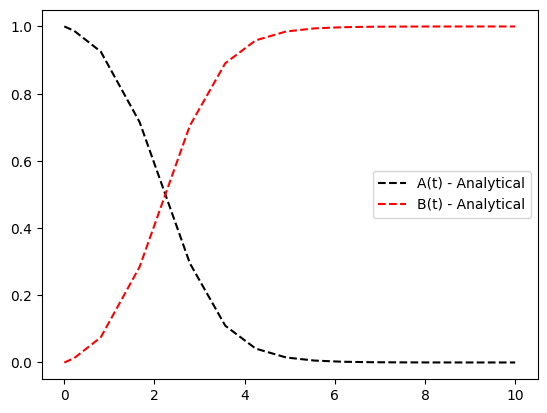

In [31]:
# plot analytical solution for comparison
f = lambda t, k1, k2, A0: (k1/k2 + A0) / (1 + k1 / (k2 * A0) * np.exp((k1 + k2*A0) * t))
plt.plot(sol.t, f(sol.t, k1, k2, A0), 'k--', label='A(t) - Analytical')
plt.plot(sol.t, A0-f(sol.t, k1, k2, A0), 'r--', label='B(t) - Analytical')
plt.legend()

array([1.58601023e-12, 6.77665844e-04, 3.64207494e+02])

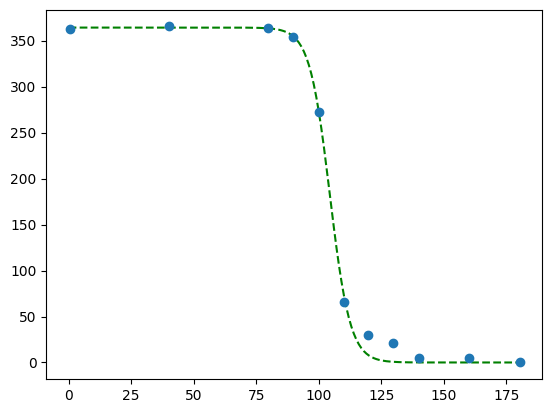

In [32]:
# fitting parameters for data from Morris et al, 2008 Biochemistry [or example]!
data = np.genfromtxt('data_morris.csv', delimiter=',')
popt, pcov = curve_fit(f, data[:, 0], data[:, 1], p0=[0.001,0.001,370])
inp = np.arange(0, data[:, 0].max(), 1)
plt.plot(inp, f(inp, *popt), 'g--', label='Fit to Morris Data')
plt.plot(data[:, 0], data[:, 1], 'o', label='Experimental Data')
popt

### Results
- numerical results agree with analytical solution perfectly; clear 2-step behaviour when "nucleation is much weaker than autocatalysis"!
- obtained numerical data via WebPlotDigitizer from Morris et al, 2008 Biochemistry; resulting fit looks okay (and ofc much stronger autocatalysis than nucleation)!
- deterministic (Finke-Watzky) model: simple / fast / easy to solve, smooth avg behaviour, good for large populations / high concentrations, useful for analytic insights & parameter fitting; ignores fluctuations and noise, can miss rare events & lag-phase variability, maybe inaccurate for low molecule counts!
- stochastic model: captures randomness & discrete reaction events, shows distribution of outcomes & lag-time variability & nucleation noise, better for small systems & low-copy-number kinetics; slower & more "expensive", harder to analyse & fit analytically, noisy results (might need several runs for statistics)!